# Recommender comparison

In [ ]:
import pandas as pd
import numpy as np
import gc

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ElPatron100/Library-Recommender-Team-Migros/main/best_hybrid_submission.csv')
df.head()

,user_id,recommendation
0,0,1 24 21 20 17 2 0 7 13 15
1,1,31 37 33 38 35 32 29 36 30 39
2,2,80 52 94 92 78 76 54 82 81 53
3,3,140 162 116 157 132 145 134 156 169 155
4,4,192 194 202 196 204 203 205 191 200 195


In [ ]:
# Load the datasets
interactions = pd.read_csv('https://raw.githubusercontent.com/ElPatron100/Library-Recommender-Team-Migros/main/interactions_train.csv')
interactions = interactions.rename(columns={'u': 'UserID', 'i': 'ItemID', 't':'timestamp'})
items = pd.read_csv("https://raw.githubusercontent.com/ElPatron100/Library-Recommender-Team-Migros/main/items.csv")
items = items.rename(columns={'i': 'ItemID'})
# Display the first rows of each dataset
display(interactions.head())
display(items.head())

,UserID,ItemID,timestamp
0,4456,8581,1.687541e+09
1,142,1964,1.679585e+09
2,362,3705,1.706872e+09
3,1809,11317,1.673533e+09
4,4384,1323,1.681402e+09


,Title,Author,ISBN Valid,Publisher,Subjects,ItemID
0,Classification décimale universelle : édition ...,NaN,9782871303336; 2871303339,Ed du CEFAL,Classification décimale universelle; Indexatio...,0
1,Les interactions dans l'enseignement des langu...,"Cicurel, Francine, 1947-",9782278058327; 2278058320,Didier,didactique--langue étrangère - enseignement; d...,1
2,Histoire de vie et recherche biographique : pe...,NaN,2343190194; 9782343190198,L'Harmattan,Histoires de vie en sociologie; Sciences socia...,2
3,Ce livre devrait me permettre de résoudre le c...,"Mazas, Sylvain, 1980-",9782365350020; 236535002X; 9782365350488; 2365...,Vraoum!,Moyen-Orient; Bandes dessinées autobiographiqu...,3
4,Les années glorieuses : roman /,"Lemaitre, Pierre, 1951-",9782702180815; 2702180817; 9782702183618; 2702...,Calmann-Lévy,France--1945-1975; Roman historique; Roman fra...,4


In [ ]:
# 1. Set pandas options to show full column content
# None means there is no maximum width limit
pd.set_option('display.max_colwidth', None)

# 2. Filter for items that have no missing values
items_complete = items.dropna()

# 3. Select a random sample of items
# n=5 picks 5 random rows; you can change this number as needed
random_items = items_complete.sample(n=5)

# Display the result
display(random_items)

,Title,Author,ISBN Valid,Publisher,Subjects,ItemID
5466,Pourquoi l'amour fait mal : l'expérience amoureuse dans la modernité /,"Illouz, Eva, 1961-",9782021081527; 2021081524,Seuil,Émotions--Société; Sexualité--Société; Relations amoureuses--Souffrance--Sociologie; Amour--Société; Société post-industrielle--Relations amoureuses; Souffrance; Amour; Sociologie; Psychologie; Relations amoureuses,5466
14909,Manuel d'entraînement : physiologie de la performance sportive et de son développement dans l'entraînement de l'enfant et de l'adolescent /,"Weineck, Jürgen",2711412989; 9782711412983,Vigot,entraînement (sport) - apprentissage (psychologie)--[manuel]; entraînement (sport)--[manuel],14909
13708,Infirmières et sexualité : entre soins et relation /,"Giami, Alain",9782810904099; 281090409X,Presses de l'EHESP,Sexualité; Soins infirmiers; Relations infirmière-patient,13708
11667,Vaud du ciel /,"Zellweger, Jean-Michel",9782889152261; 288915226X; 9782889152278; 2889152278; 9782889152285; 2889152286; 9782889152773; 2889152774,Genoud Arts graphiques; Presses polytechniques et universitaires romandes,Photographies aériennes--Vaud (Suisse),11667
12580,"La communication écrite en Suisse : lettres, courriels et autres formes de correspondance mises au goût du jour /","Schnyder, Fabienne 1964-....",9782606014230; 2606014235,Editions Loisirs et pédagogie,Communication écrite; Correspondance; Guides pratiques,12580


In [ ]:
#Let’s check how many unique users and items we have in this dataset.
n_users = interactions.UserID.nunique()
n_items = interactions.ItemID.nunique()
print(f'Number of users = {n_users}, \n Number of books = {n_items} \n Number of interactions = {len(interactions)}')


Number of users = 7838, 
 Number of books = 15109 
 Number of interactions = 87047


In [ ]:
# Calculate the number of rentals per user
user_counts = interactions['UserID'].value_counts()

# Count how many users have rented fewer than 3 books
threshold = 4
users_below_threshold = (user_counts < threshold).sum()
total_users = interactions['UserID'].nunique()

# Calculate the percentage
percentage_low_rentals = (users_below_threshold / total_users) * 100

print(f"--- For your README Limitation Section ---")
print(f"More than {percentage_low_rentals:.1f}% of users have rented fewer than {threshold} books.")

--- For your README Limitation Section ---
More than 31.2% of users have rented fewer than 4 books.


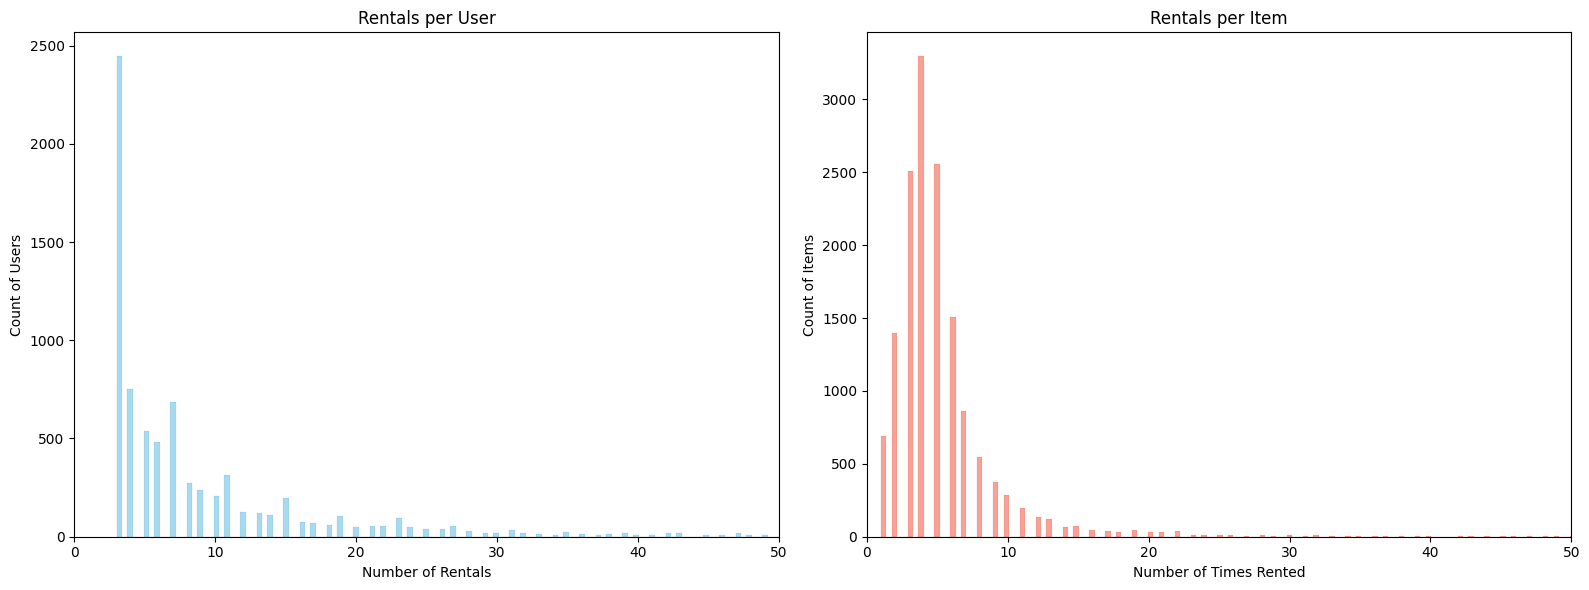

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the counts
user_counts = interactions.groupby('UserID').size()
item_counts = interactions.groupby('ItemID').size()

# 2. Set up the plotting area
plt.figure(figsize=(16, 6))

# Plot Distribution per User (Zoomed)
plt.subplot(1, 2, 1)
sns.histplot(user_counts, bins=1000, kde=False, color='skyblue')
plt.xlim(0, 50) # The Zoom
plt.title('Rentals per User')
plt.xlabel('Number of Rentals')
plt.ylabel('Count of Users')

# Plot Distribution per Item (Zoomed)
plt.subplot(1, 2, 2)
sns.histplot(item_counts, bins=1000, kde=False, color='salmon')
plt.xlim(0, 50) # The Zoom
plt.title('Rentals per Item')
plt.xlabel('Number of Times Rented')
plt.ylabel('Count of Items')

plt.tight_layout()
plt.savefig('rentals_per_user_item.png')
plt.show()

In [ ]:
# 1. Number of books rented more than 10 times
item_counts = interactions.groupby('ItemID').size()
books_more_than_10 = (item_counts > 10).sum()
total_item = interactions['ItemID'].nunique()
percentage_books_gt_10 = (books_more_than_10 / total_item) * 100

# 2. Percentage of users who rent more than 20 books
user_counts = interactions.groupby('UserID').size()
users_more_than_20 = (user_counts > 20).sum()
total_users = interactions['UserID'].nunique()
percentage_users_gt_20 = (users_more_than_20 / total_users) * 100

print(f"Percentage of books rented more than 10 times: {percentage_books_gt_10: .2f}%")
print(f"Percentage of users who rent more than 20 books: {percentage_users_gt_20:.2f}%")

Percentage of books rented more than 10 times:  7.17%
Percentage of users who rent more than 20 books: 12.67%


In [ ]:
import pandas as pd

# 1. Ensure the timestamp column is in datetime format
# (Unit='s' is common if your timestamps are Unix integers)
interactions['timestamp_dt'] = pd.to_datetime(interactions['timestamp'], unit='s')

# 2. Find the earliest and latest dates
min_date = interactions['timestamp_dt'].min()
max_date = interactions['timestamp_dt'].max()

# 3. Calculate the difference in years
time_span = max_date - min_date
years = time_span.days / 365.25

print(f"Dataset starts on: {min_date.date()}")
print(f"Dataset ends on:   {max_date.date()}")
print(f"Total time span:   {years:.2f} years")

Dataset starts on: 2023-01-02
Dataset ends on:   2024-10-14
Total time span:   1.78 years


In [ ]:
# 1. Average books rented per user
# Group by UserID and count how many items each user has
user_rentals = interactions.groupby('UserID').size()
avg_rentals_per_user = user_rentals.mean()

# 2. Average times each book has been rented
# Group by ItemID and count how many times each item appears
item_rentals = interactions.groupby('ItemID').size()
avg_rentals_per_item = item_rentals.mean()

print(f"Average books rented per user: {avg_rentals_per_user:.2f}")
print(f"Average times a book is rented: {avg_rentals_per_item:.2f}")

Average books rented per user: 11.11
Average times a book is rented: 5.76


/tmp/ipykernel_18406/2254646735.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Keyword', data=top_df, palette='viridis')


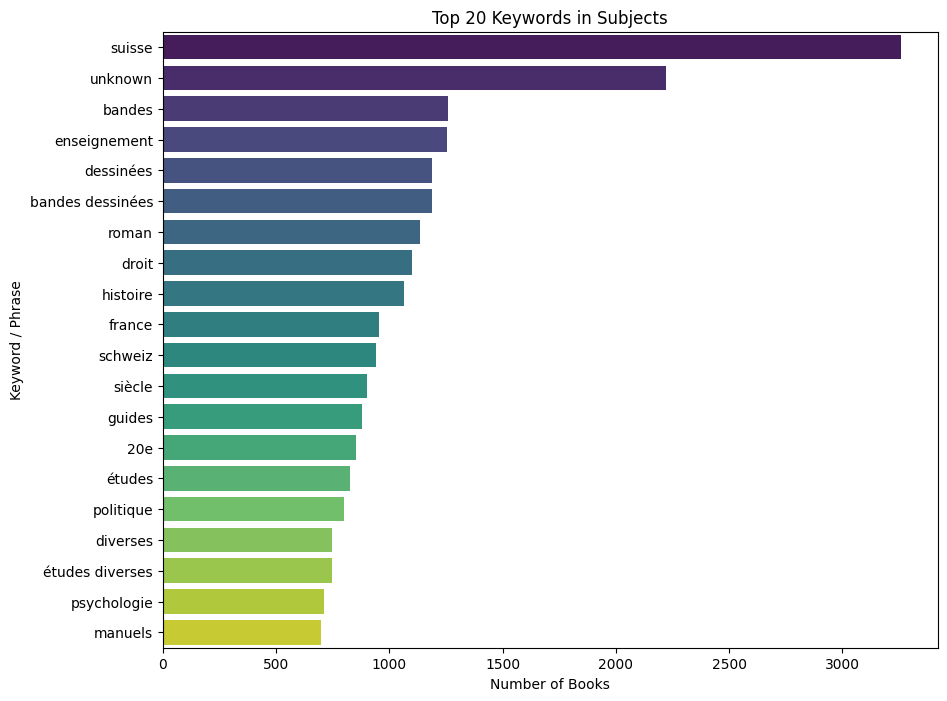

Most Frequent Subject Keywords:
            Keyword  Frequency
0            suisse       3258
1           unknown       2223
2            bandes       1260
3      enseignement       1255
4         dessinées       1189
5  bandes dessinées       1189
6             roman       1134
7             droit       1098
8          histoire       1066
9            france        955


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re

# 1. Identify and Clean the Subject Column
# Replace 'Subjects Item' with your actual column name if different
subj_col = [c for c in items.columns if 'Subject' in c][0]
subject_data = items[subj_col].fillna('Unknown').astype(str)

# 2. Initialize CountVectorizer
# We use stop_words='english' and add common French stop words
# to ensure we get meaningful academic keywords.
french_stop_words = ['de', 'la', 'le', 'et', 'des', 'en', 'du', 'sur', 'pour', 'dans']
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words()) + french_stop_words

vectorizer = CountVectorizer(
    stop_words=custom_stop_words,
    ngram_range=(1, 2), # This finds both single words and 2-word phrases
    max_features=1000   # Focus on the most important terms
)

# 3. Fit and Transform the Subject Text
word_counts = vectorizer.fit_transform(subject_data)
sum_words = word_counts.sum(axis=0)

# 4. Extract word frequencies
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 5. Visualize the Top 20 Keywords
top_df = pd.DataFrame(words_freq[:20], columns=['Keyword', 'Frequency'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Frequency', y='Keyword', data=top_df, palette='viridis')
plt.title(f'Top 20 Keywords in {subj_col}')
plt.xlabel('Number of Books')
plt.ylabel('Keyword / Phrase')
plt.savefig('top_keywords')
plt.show()

# Print the top results for your EDA report
print("Most Frequent Subject Keywords:")
print(top_df.head(10))